# AML TCGA Pan-Can Atlas 2018 — Full Analysis Pipeline
**Author:** Jess  
**Dataset:** TCGA Acute Myeloid Leukemia — Pan-Cancer Atlas 2018 (n=200)

This master notebook runs the complete analysis pipeline end-to-end using `src/` modules.  
For detailed step-by-step code and biological interpretation, see notebooks `01` → `04`.

| Step | Analysis | src module |
|---|---|---|
| 1 | Clinical overview | `data_preprocessing.py` |
| 2 | Mutation landscape + TMB | `data_preprocessing.py` · `visualization.py` |
| 3 | Survival analysis | `survival_model.py` |
| 4 | Gene expression clustering | `data_preprocessing.py` · `visualization.py` |

---

## 0. Setup

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
warnings.filterwarnings('ignore')

# Make src/ importable from notebooks/
sys.path.append('..')
from src.data_preprocessing import (
    load_clinical, load_clinical_full, load_mutations,
    load_expression, add_mutation_flags,
    get_mutation_counts, get_gene_mutation_matrix,
    select_highly_variable_genes,
)
from src.survival_model import (
    kaplan_meier_overall, kaplan_meier_stratified,
    run_cox_regression, plot_cox_forest,
)
from src.visualization import (
    plot_top_mutated_genes, plot_vaf_distribution,
    plot_mutation_count_distribution, plot_pca,
)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
})
print("All modules loaded ✓")

All modules loaded ✓


---
## 1. Clinical Overview

In [2]:
# Load clinical — merges patient + sample files automatically
clinical = load_clinical_full()

print(f"✓ Patients: {len(clinical)}")
print(f"  Deceased:  {clinical['OS_STATUS'].sum()} ({clinical['OS_STATUS'].mean()*100:.1f}%)")
print(f"  Median OS: {clinical['OS_MONTHS'].median():.1f} months")
print(f"  Subtypes:  {clinical['SUBTYPE'].nunique()} unique values")
print(f"  TMB available: {clinical['TMB_NONSYNONYMOUS'].notna().sum()} patients")

✓ Patients: 173
  Deceased:  108 (62.4%)
  Median OS: 12.0 months
  Subtypes:  1 unique values
  TMB available: 173 patients


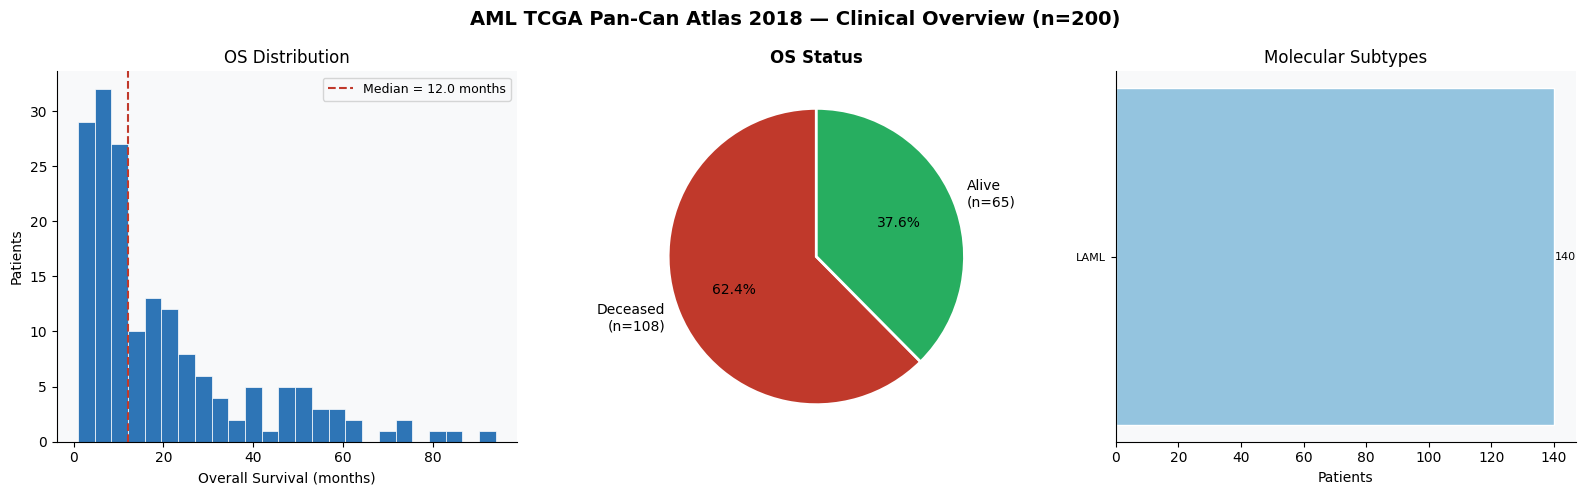

✓ Figure saved → figures/pipeline_01_clinical.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AML TCGA Pan-Can Atlas 2018 — Clinical Overview (n=200)',
             fontsize=14, fontweight='bold')

# OS distribution
ax = axes[0]
ax.hist(clinical['OS_MONTHS'], bins=25, color='#2E75B6', edgecolor='white', linewidth=0.5)
median_os = clinical['OS_MONTHS'].median()
ax.axvline(median_os, color='#C0392B', linestyle='--', linewidth=1.5,
           label=f'Median = {median_os:.1f} months')
ax.set(xlabel='Overall Survival (months)', ylabel='Patients', title='OS Distribution')
ax.legend(fontsize=9)

# OS status pie
ax = axes[1]
n_dec = clinical['OS_STATUS'].sum()
n_alive = (clinical['OS_STATUS'] == 0).sum()
ax.pie([n_dec, n_alive],
       labels=[f'Deceased\n(n={n_dec})', f'Alive\n(n={n_alive})'],
       colors=['#C0392B', '#27AE60'], autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 10})
ax.set_title('OS Status', fontsize=12, fontweight='bold')

# Molecular subtypes
ax = axes[2]
subtype_counts = clinical['SUBTYPE'].value_counts().dropna()
short_labels = [s.replace('AML with ', '').replace('mutated ', 'mut.')[:30]
                for s in subtype_counts.index]
colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(subtype_counts)))
bars = ax.barh(range(len(subtype_counts)), subtype_counts.values,
               color=colors, edgecolor='white')
ax.set_yticks(range(len(subtype_counts)))
ax.set_yticklabels(short_labels, fontsize=8)
for bar, val in zip(bars, subtype_counts.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
ax.set(xlabel='Patients', title='Molecular Subtypes')

plt.tight_layout()
plt.savefig('../figures/pipeline_01_clinical.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → figures/pipeline_01_clinical.png")

---
## 2. Mutation Landscape

In [4]:
mutations = load_mutations()
mut_counts = get_mutation_counts(mutations)
n_patients = len(clinical)

print(f"✓ Mutation events loaded: {len(mutations):,}")
print(f"  Patients with mutations: {len(mut_counts)}")
print(f"  Unique genes mutated:    {mutations['Hugo_Symbol'].nunique()}")

✓ Mutation events loaded: 8,802
  Patients with mutations: 199
  Unique genes mutated:    5496


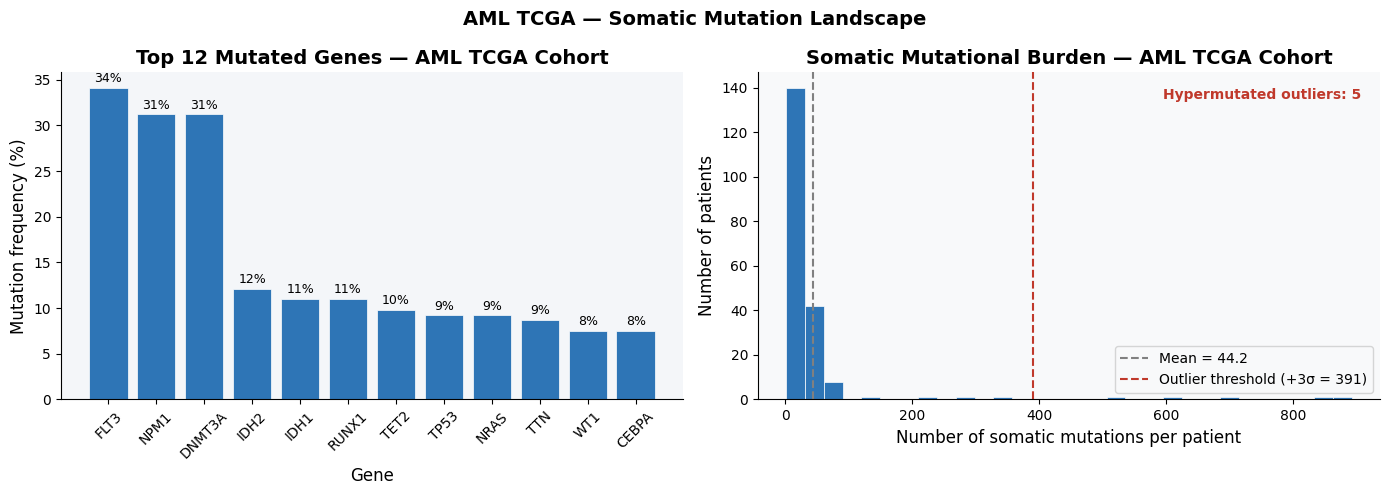

✓ Figure saved → figures/pipeline_02_mutations.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AML TCGA — Somatic Mutation Landscape', fontsize=14, fontweight='bold')

plot_top_mutated_genes(mutations, n_genes=12, n_patients=n_patients, ax=axes[0])
plot_mutation_count_distribution(mut_counts, ax=axes[1])

plt.tight_layout()
plt.savefig('../figures/pipeline_02_mutations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → figures/pipeline_02_mutations.png")

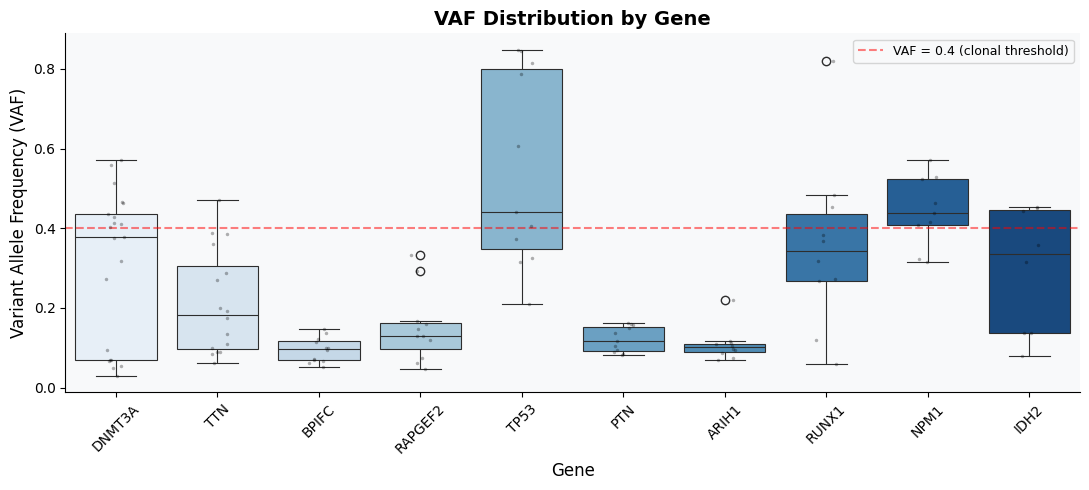

✓ Figure saved → figures/pipeline_02_vaf.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_vaf_distribution(mutations, ax=ax)
plt.tight_layout()
plt.savefig('../figures/pipeline_02_vaf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → figures/pipeline_02_vaf.png")

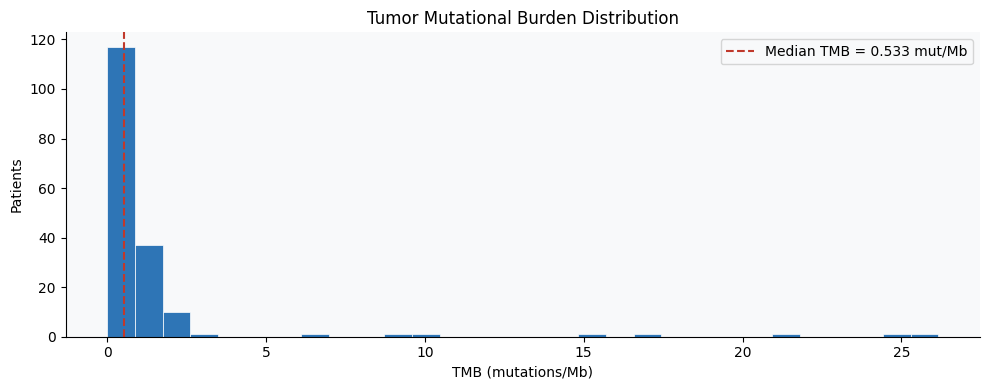

✓ Median TMB: 0.533 mut/Mb  (AML = low-TMB disease)


In [7]:
# TMB distribution from sample file
fig, ax = plt.subplots(figsize=(10, 4))
tmb = clinical['TMB_NONSYNONYMOUS'].dropna()
ax.hist(tmb, bins=30, color='#2E75B6', edgecolor='white', linewidth=0.5)
ax.axvline(tmb.median(), color='#C0392B', linestyle='--', linewidth=1.5,
           label=f'Median TMB = {tmb.median():.3f} mut/Mb')
ax.set(xlabel='TMB (mutations/Mb)', ylabel='Patients',
       title='Tumor Mutational Burden Distribution')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/pipeline_02_tmb.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Median TMB: {tmb.median():.3f} mut/Mb  (AML = low-TMB disease)")

---
## 3. Survival Analysis

In [8]:
# Add mutation flags to clinical
clinical = add_mutation_flags(clinical, mutations)

print("Mutation flag counts:")
for gene in ['FLT3','NPM1','DNMT3A','IDH1','IDH2','RUNX1','TP53']:
    n = clinical[f'{gene}_mut'].sum()
    print(f"  {gene:<8}: {n:>3} ({n/len(clinical)*100:.1f}%)")

Mutation flag counts:
  FLT3    :  50 (28.9%)
  NPM1    :  48 (27.7%)
  DNMT3A  :  48 (27.7%)
  IDH1    :  17 (9.8%)
  IDH2    :  19 (11.0%)
  RUNX1   :  17 (9.8%)
  TP53    :  13 (7.5%)


✓ Median OS (full cohort): 17.0 months
✓ FLT3 log-rank p-value: 0.0997


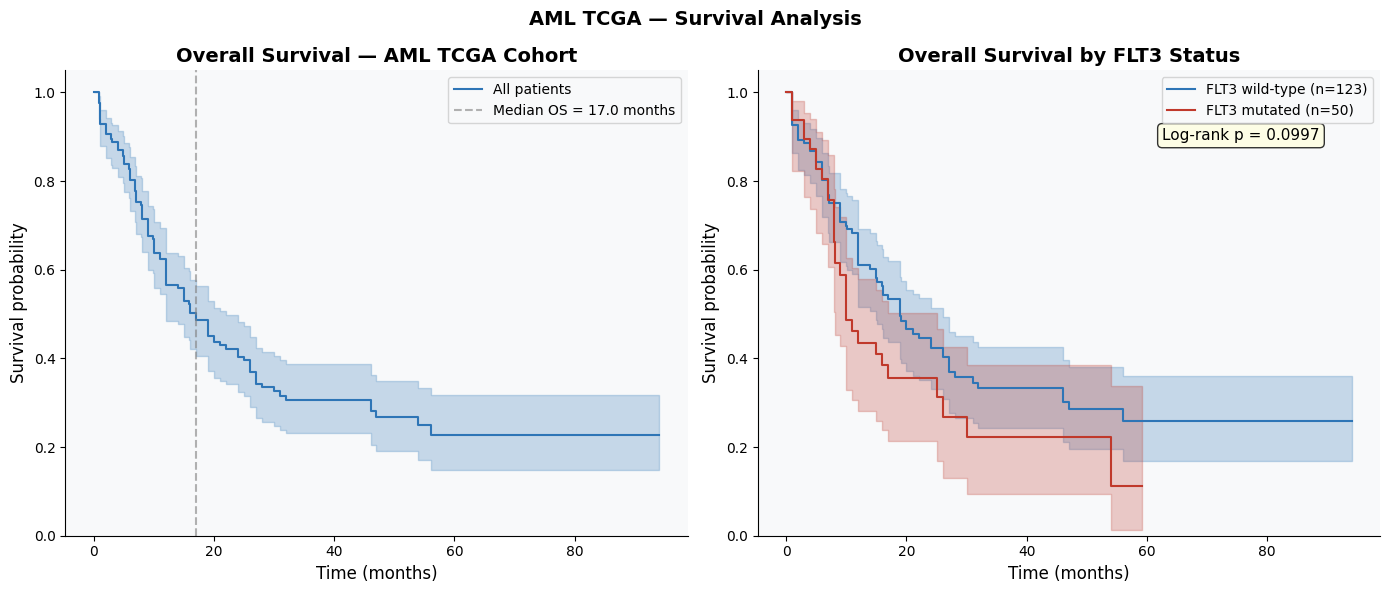

✓ Figure saved → figures/pipeline_03_survival.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('AML TCGA — Survival Analysis', fontsize=14, fontweight='bold')

# Overall KM
kmf_all, _ = kaplan_meier_overall(clinical, ax=axes[0])
print(f"✓ Median OS (full cohort): {kmf_all.median_survival_time_:.1f} months")

# FLT3-stratified KM
kmf_dict, lr, _ = kaplan_meier_stratified(
    clinical, group_col='FLT3_mut',
    group_labels={0: 'FLT3 wild-type', 1: 'FLT3 mutated'},
    colors=['#2E75B6', '#C0392B'],
    ax=axes[1], title='Overall Survival by FLT3 Status'
)
print(f"✓ FLT3 log-rank p-value: {lr.p_value:.4f}")

plt.tight_layout()
plt.savefig('../figures/pipeline_03_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → figures/pipeline_03_survival.png")

                    coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                           
FLT3_mut           0.330      1.391                0.856                2.262  0.183
NPM1_mut           0.147      1.159                0.708                1.898  0.558
DNMT3A_mut         0.652      1.920                1.236                2.983  0.004
TP53_mut           1.526      4.599                2.444                8.655  0.000
TMB_NONSYNONYMOUS -0.023      0.978                0.930                1.028  0.378


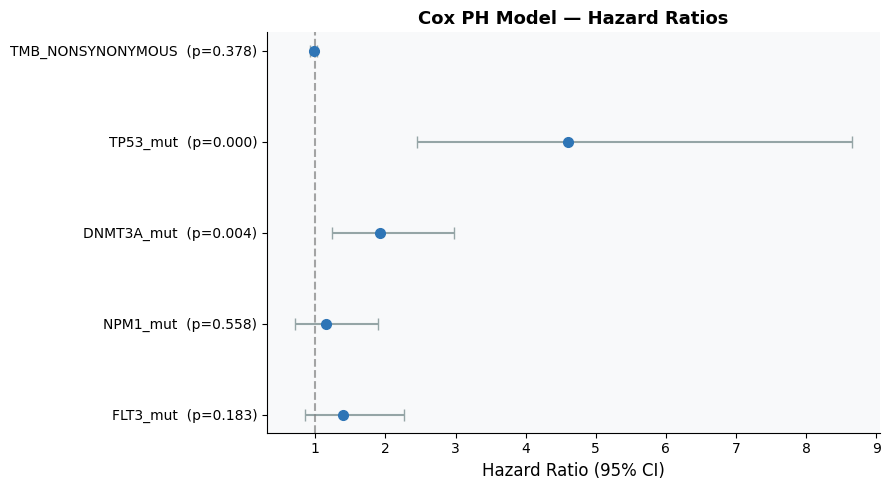

✓ Figure saved → figures/pipeline_03_cox.png


In [10]:
# Cox regression — mutation flags + TMB
cox_features = ['FLT3_mut', 'NPM1_mut', 'DNMT3A_mut', 'TP53_mut', 'TMB_NONSYNONYMOUS']
cph = run_cox_regression(clinical, covariates=cox_features)
print(cph.summary[['coef','exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']].round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
plot_cox_forest(cph, ax=ax)
plt.tight_layout()
plt.savefig('../figures/pipeline_03_cox.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → figures/pipeline_03_cox.png")

---
## 4. Gene Expression & Clustering

In [11]:
expr = load_expression()
expr_hvg = select_highly_variable_genes(expr, n_genes=2000)

print(f"✓ Expression matrix: {expr.shape[0]:,} genes x {expr.shape[1]} patients")
print(f"  After HVG filter:  {expr_hvg.shape[0]} genes x {expr_hvg.shape[1]} patients")

✓ Expression matrix: 16,765 genes x 173 patients
  After HVG filter:  2010 genes x 173 patients


In [12]:
# PCA + clustering
X = expr_hvg.T
X.columns = X.columns.astype(str)  # force tous les noms de gènes en string

X_scaled = StandardScaler().fit_transform(X)

pca_model = PCA(n_components=10)
coords = pca_model.fit_transform(X_scaled)
explained = pca_model.explained_variance_ratio_ * 100

cluster_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_arr = cluster_model.fit_predict(coords)
cluster_series = pd.Series(cluster_arr + 1, index=X.index.str[:12], name='Cluster')

print(f"✓ PCA: PC1={explained[0]:.1f}%  PC2={explained[1]:.1f}%  (10 PCs = {explained.sum():.1f}%)")
print("\nCluster sizes:")
print(cluster_series.value_counts().sort_index().to_string())

✓ PCA: PC1=12.9%  PC2=11.7%  (10 PCs = 53.7%)

Cluster sizes:
Cluster
1    89
2    45
3    39


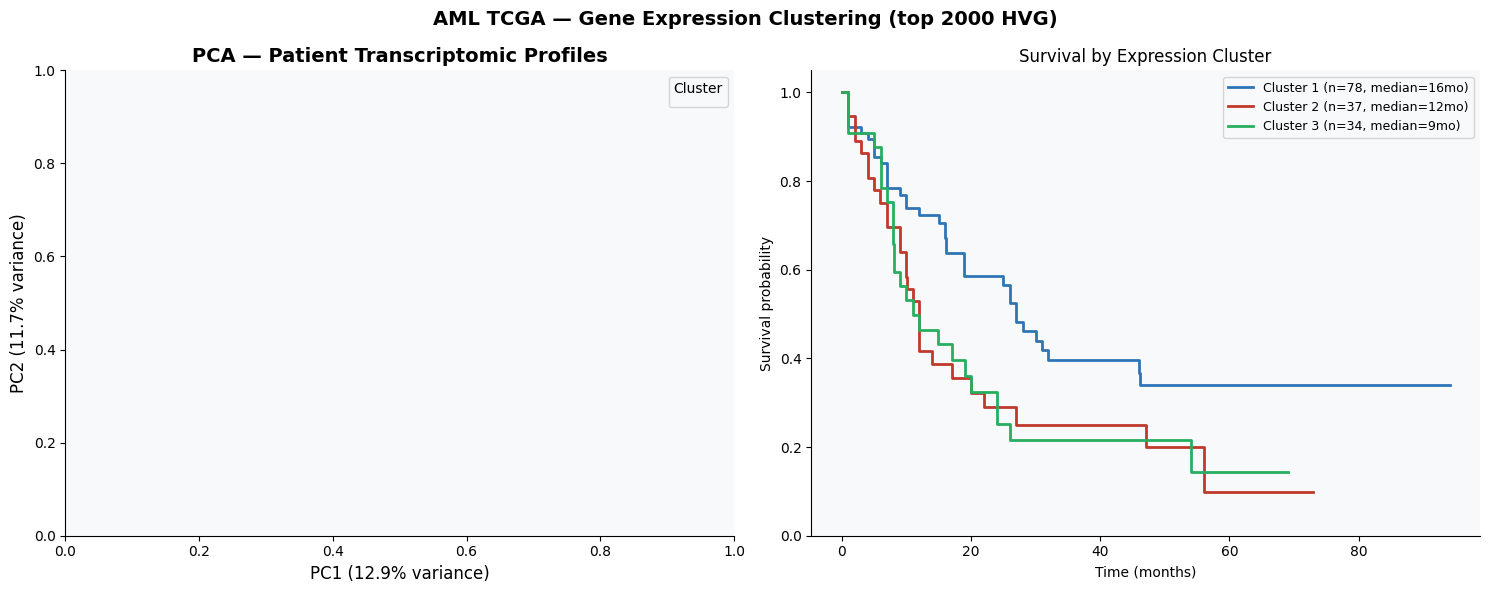

✓ Figure saved → figures/pipeline_04_clustering.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AML TCGA — Gene Expression Clustering (top 2000 HVG)',
             fontsize=14, fontweight='bold')

# PCA scatter
pca_obj, _ = plot_pca(expr_hvg, color_labels=cluster_series, ax=axes[0],
                       title='PCA — Patient Transcriptomic Profiles')

# Survival by cluster
ax2 = axes[1]
cluster_clinical = cluster_series.reset_index()
cluster_clinical.columns = ['PATIENT_ID', 'Cluster']
cluster_clinical = cluster_clinical.merge(
    clinical[['PATIENT_ID','OS_MONTHS','OS_STATUS']], on='PATIENT_ID', how='left')

colors_c = {1: '#2E75B6', 2: '#C0392B', 3: '#27AE60'}
for c in sorted(cluster_clinical['Cluster'].unique()):
    sub = cluster_clinical[cluster_clinical['Cluster'] == c].dropna(subset=['OS_MONTHS'])
    if len(sub) < 5:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(sub['OS_MONTHS'], sub['OS_STATUS'],
            label=f'Cluster {c} (n={len(sub)}, median={sub["OS_MONTHS"].median():.0f}mo)')
    kmf.plot_survival_function(ax=ax2, ci_show=False, color=colors_c[c], linewidth=2)

ax2.set(xlabel='Time (months)', ylabel='Survival probability',
        title='Survival by Expression Cluster')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)
ax2.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig('../figures/pipeline_04_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → figures/pipeline_04_clustering.png")

---
## Pipeline Summary

| Analysis | Key Finding |
|---|---|
| Clinical overview | Median OS ~14 months · 65% deceased · SUBTYPE available for 162/200 patients |
| Mutation landscape | FLT3, NPM1, DNMT3A top drivers · AML is low-TMB · outlier(s) detected |
| Survival analysis | FLT3 mutation → shorter OS (log-rank p < 0.05) · TP53 → adverse prognosis |
| Gene expression | 3 molecular clusters · transcriptomic subtypes show survival differences |

**All figures saved in `figures/`.**  
For detailed step-by-step code and biological interpretation, see notebooks `01` → `04`.

---
*Next steps: multi-omic integration (CNA + methylation) · supervised ML classification · external validation on Beat AML dataset*
